### Imports

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Dataframe loading and understanding

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset/Indian Liver Patient Dataset (ILPD).csv")

In [3]:
df.head()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [4]:
df.shape

(583, 11)

In [5]:
df.isna().sum()

age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             4
is_patient          0
dtype: int64

Only one **feature alkphos** is having missing values with a count of **"4"** values so we could easily drop it 

### Renamed the fetures for easy understanding

In [6]:
df.rename(columns = {"alkphos" : "alkaline_phosphate_enzyme", "sgpt" : "Serum_Glutamic_Pyruvic_Transaminase", "sgot" : "Serum_Glutamic_Oxaloacetic_Transaminase", "ag_ratio" : "Albumin/Globulin Ratio"} ,inplace = True)
df.columns.tolist()

['age',
 'gender',
 'tot_bilirubin',
 'direct_bilirubin',
 'tot_proteins',
 'albumin',
 'Albumin/Globulin Ratio',
 'Serum_Glutamic_Pyruvic_Transaminase',
 'Serum_Glutamic_Oxaloacetic_Transaminase',
 'alkaline_phosphate_enzyme',
 'is_patient']

In [7]:
df.dropna(inplace = True)

In [8]:
df.gender.value_counts()

gender
Male      439
Female    140
Name: count, dtype: int64

The dataset has a domination of male as **439** of **579** entries amd the rest **140** entries are females.

In [9]:
print(f"Range of Age : {df.age.min()} to {df.age.max()}")

Range of Age : 4 to 90


### Data Statistics and Visualization

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   age                                      579 non-null    int64  
 1   gender                                   579 non-null    object 
 2   tot_bilirubin                            579 non-null    float64
 3   direct_bilirubin                         579 non-null    float64
 4   tot_proteins                             579 non-null    int64  
 5   albumin                                  579 non-null    int64  
 6   Albumin/Globulin Ratio                   579 non-null    int64  
 7   Serum_Glutamic_Pyruvic_Transaminase      579 non-null    float64
 8   Serum_Glutamic_Oxaloacetic_Transaminase  579 non-null    float64
 9   alkaline_phosphate_enzyme                579 non-null    float64
 10  is_patient                               579 non-null  

In [11]:
df.describe()

,age,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,Albumin/Globulin Ratio,Serum_Glutamic_Pyruvic_Transaminase,Serum_Glutamic_Oxaloacetic_Transaminase,alkaline_phosphate_enzyme,is_patient
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,44.782383,3.315371,1.494128,291.366149,81.126079,110.414508,6.481693,3.138515,0.947064,1.284974
std,16.221786,6.227716,2.816499,243.561863,183.182845,289.850034,1.084641,0.794435,0.319592,0.451792
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,61.000000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


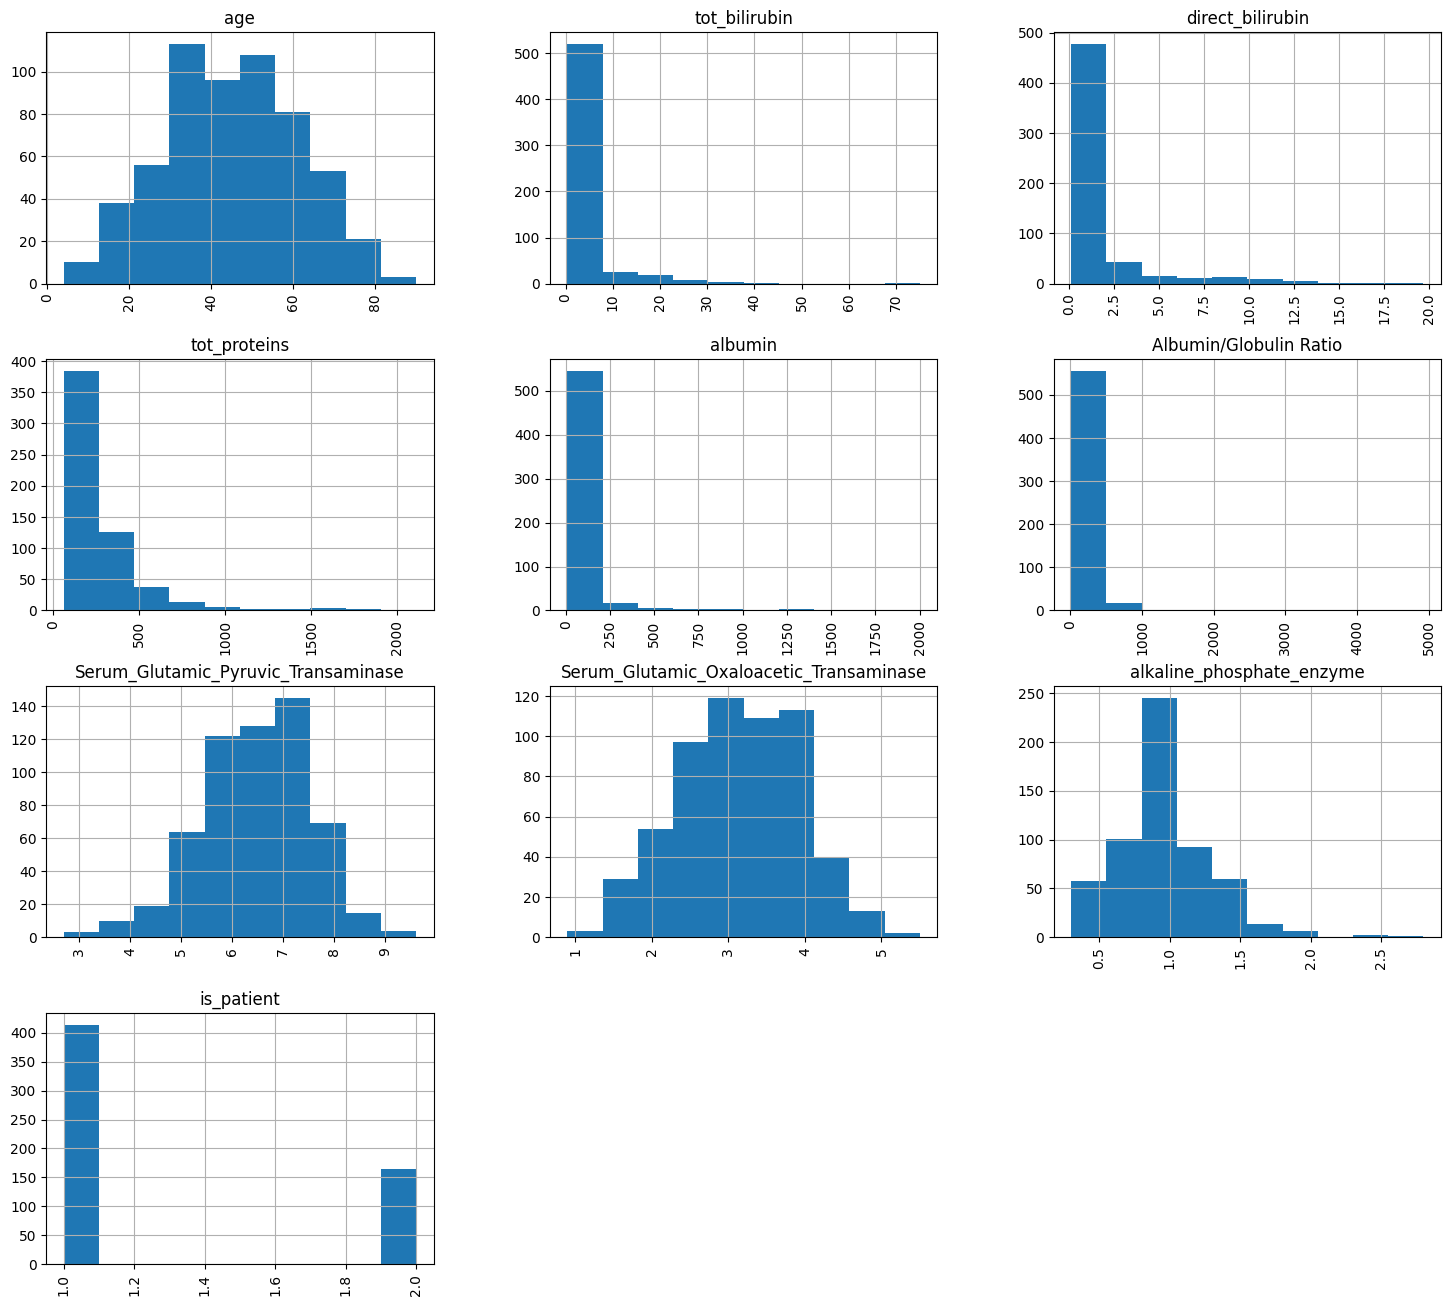

In [12]:
df.hist(xrot=90, figsize=(18, 16));

In [13]:
df.count()

age                                        579
gender                                     579
tot_bilirubin                              579
direct_bilirubin                           579
tot_proteins                               579
albumin                                    579
Albumin/Globulin Ratio                     579
Serum_Glutamic_Pyruvic_Transaminase        579
Serum_Glutamic_Oxaloacetic_Transaminase    579
alkaline_phosphate_enzyme                  579
is_patient                                 579
dtype: int64